<a href="https://colab.research.google.com/github/DataFriend101/Machine_Learning/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question is: **Can we identify content that is at risk of declining early enough to prioritize which pages should receive attention?**

The **goal** is to help content teams **prioritize pages for review or refresh** based on measurable signals associated with declining performance, rather than relying on a simple rule or reviewing pages manually.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This analysis uses the FlyRank ML Internship dataset, release **flyrank_pseudonymized_warehouse_release_v20260703**, based on anonymized production search and content-performance data. For this project, I used the small, **anonymized content_refresh_anonymized.csv** slice provided for the internship. It contains one row per pseudonymized content item, with observed search and engagement metrics, content metadata, age/freshness fields, and derived comparison windows.

The dataset **contains no client names, domains, URLs, page titles, keywords, or raw search queries**. Pseudonymized content_id and client_id fields were used only for grouping and validation and were not included as model features.

The analysis focused on **observable signals available in the provided dataset**. Product decision flags and composite scores were not used, so the model was built from measurable performance and content signals rather than reproducing an existing product decision. The final analysis and published artifacts contain no private client information or identifying data and are framed as decision-support analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Model choice**

I used a Random Forest classifier because it can capture nonlinear relationships and interactions among multiple content-performance signals without requiring those relationships to be linear.


**Features**

The final model uses five observable features:

impressions_90d
ctr
avg_position
content_age_days
days_since_last_update

Pseudonymized client_id and content_id were used only for grouping and validation and were not used as model features.


**Label definition**

The target, is_declining_label, was created from the observed trend_direction field:

1 = trend_direction == "down"

0 = otherwise

The positive rate in the full dataset was 54.2%.

This label represents an observed performance trend in the available data. It is not treated as proof of future decline or as a causal outcome.


**Baseline**

The Week 4 baseline ranked pages using a simple combination of recent visibility and CTR opportunity. The Random Forest was evaluated against this baseline using the same test split and Precision@50 metric.


**Validation design**

The primary Week 5 evaluation used an 80/20 client-grouped split with random_state=42. Pages from the same client were kept entirely within either the training or test set, providing a more realistic test of generalization to unseen clients.

In Week 6, I strengthened this evaluation using 5-fold client-grouped cross-validation. The same Random Forest configuration was evaluated across five client-grouped folds to reduce dependence on a single train/test split.


**Leakage checks**

I audited the final feature set for three potential forms of leakage:

Label-derived features: whether a feature directly encoded the target.
Future or overlapping time information: whether a feature could contain information from the outcome period.
Decision-derived features: whether a feature reproduced an existing product decision or composite score.

No obvious leakage was identified for content_age_days or days_since_last_update. impressions_90d, ctr, and avg_position require timeline verification because they are performance measures that could potentially overlap with the period used to define the observed trend label.

Therefore, the results are framed as measured and directional, rather than as evidence of causal or guaranteed predictive performance.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("content_refresh_anonymized.csv")

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

features = [
    "impressions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update"
]

target = "is_declining_label"

X = df[features].copy()
y = df[target].copy()

print("Rows:", len(df))
print("Features:", features)
print("Target:", target)
print("Positive rate:", y.mean())

Rows: 30000
Features: ['impressions_90d', 'ctr', 'avg_position', 'content_age_days', 'days_since_last_update']
Target: is_declining_label
Positive rate: 0.5420666666666667


In [2]:
groups = df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [3]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

On the Week 5 client-grouped test split, the **Random Forest achieved a Precision@50 of 0.680, compared with 0.440 for the Week 4 baseline and 0.511 for the test-set base rate**.

This means that 34 of the model's top 50 ranked pages were labeled as declining, compared with 22 of the top 50 pages selected by the baseline. The Random Forest therefore showed higher measured ranking precision than the simpler rule on the same test set and metric.

The single-split result was then tested more robustly using 5-fold client-grouped validation. Across the **five folds, Precision@50 was 0.800, 0.840, 0.600, 0.820, and 0.780, producing a mean of 0.768 with a standard deviation of 0.086**.

The variation across folds shows that performance differs across client groups. The 5-fold result provides stronger directional evidence than relying on a single held-out split, but it should still be interpreted as measured performance on this dataset rather than guaranteed performance on future clients.

**Feature importance**

The Random Forest relied most strongly on impressions_90d (0.322), avg_position (0.291), and content_age_days (0.207). ctr contributed 0.133, while days_since_last_update contributed 0.047.

In [7]:
def precision_at_k(y_true, scores, k=50):
    scores = pd.Series(scores, index=y_true.index)
    top_k = scores.sort_values(ascending=False).head(k).index
    return y_true.loc[top_k].mean()


model_scores = model.predict_proba(X_test)[:, 1]

model_precision_50 = precision_at_k(
    y_test,
    model_scores,
    k=50
)

base_rate = y_test.mean()
baseline_precision_50 = 0.440

comparison = pd.DataFrame({
    "Method": [
        "Base rate",
        "Week 4 Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        base_rate,
        baseline_precision_50,
        model_precision_50
    ]
})

comparison

,Method,Precision@50
0,Base rate,0.510952
1,Week 4 Baseline,0.440000
2,Random Forest,0.680000


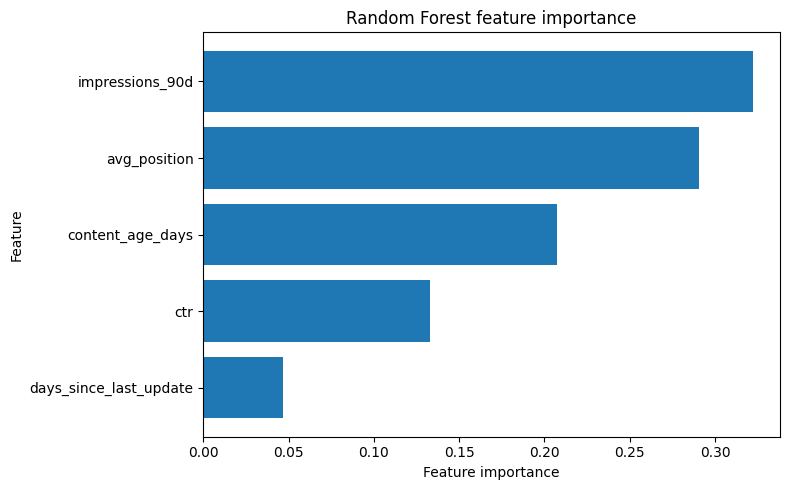

In [9]:
# Chart 1: Random Forest feature importance
import matplotlib.pyplot as plt

feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=features
    )
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance.index,
    feature_importance.values
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

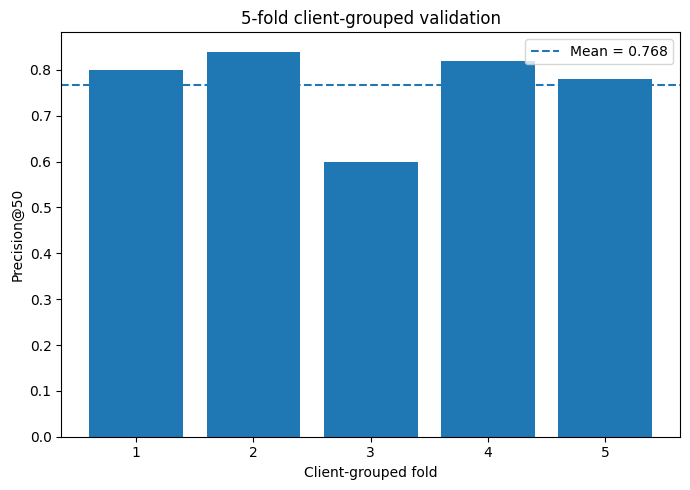

In [10]:
# Chart 2: 5-fold client-grouped validation
fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Precision@50": [0.800, 0.840, 0.600, 0.820, 0.780]
})

plt.figure(figsize=(7, 5))
plt.bar(
    fold_results["Fold"].astype(str),
    fold_results["Precision@50"]
)
plt.axhline(
    fold_results["Precision@50"].mean(),
    linestyle="--",
    label="Mean = 0.768"
)
plt.xlabel("Client-grouped fold")
plt.ylabel("Precision@50")
plt.title("5-fold client-grouped validation")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

This analysis identifies **patterns associated with observed declining performance**; it does not establish that any feature causes a decline or that changing a feature will improve performance.

The analysis uses the provided 30,000-row anonymized content slice rather than the full FlyRank production warehouse. The findings should therefore be treated as directional and may not generalize to every client, content type, or search environment.

Finally, the **action queue is intended to prioritize human review, not automatically determine which pages should be refreshed, rewritten, redirected, or removed**. A high model score does not guarantee that an intervention will improve performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

#### **1. Prioritize high-scoring pages for human review**

Use the model score to create a ranked review queue rather than treating every page equally. Pages with higher scores can be reviewed first because the model identifies them as having a stronger association with the observed declining label.

**Action:** Review the highest-priority pages first and investigate the signals behind their ranking.

#### **2. Investigate visibility and ranking signals**

impressions_90d and avg_position were the two strongest model features. Pages showing weak recent visibility or less favorable observed ranking should therefore receive closer investigation.

**Action:** Review whether the page remains relevant, aligned with search intent, and strategically important before deciding on an intervention.

####**3. Review content age and freshness alongside performance**

content_age_days was the third strongest model feature. Older content may deserve additional attention when it also shows other signals associated with decline.

**Action:** Check whether information is outdated or whether a refresh is warranted, but do not use age alone as an automatic refresh trigger.

**Human-review rule**

The model should function as a prioritization layer:

rank → investigate → review → decide → act

The model should not automatically publish or rewrite content, delete pages, make redirects or canonical changes, or override editorial judgment.
The recommendations are intended as decision support, not automated decisions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

#### **1 — Model vs baseline**

A table comparing the base rate, Week 4 baseline, and Random Forest using Precision@50 on the same client-grouped test split.

**Takeaway:** The Random Forest achieved 0.680 Precision@50 compared with 0.440 for the baseline.

####**2 — Feature importance**

A ranked bar chart showing the Random Forest's feature importance.

**Takeaway:** impressions_90d, avg_position, and content_age_days were the strongest model signals.

####**3 — Validation stability**

A chart showing Precision@50 across the five client-grouped validation folds.

**Takeaway:** Performance varied across folds, with Precision@50 ranging from 0.600 to 0.840 and a mean of 0.768.

####**4 — Action playbook**

A concise table connecting model signals to recommended human-review actions.

**Takeaway:** The model output is used to prioritize investigation, while final content decisions remain with a human reviewer.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.